# American option pricing

Pricing a finite-maturity American put on a single underlying. The
option holder chooses each period whether to **exercise now** (collect
the intrinsic payoff and walk away) or **hold** (continue and face the
same decision next period). Unlike European options there is no
closed-form Black-Scholes formula — we benchmark against a CRR
binomial tree.

## Problem

Underlying $S_t$ follows risk-neutral GBM in discrete time:

$$ S_{t+1} = S_t \, \exp\!\Bigl( (r - \tfrac12\sigma^2)\,\Delta t + \sigma\sqrt{\Delta t}\, Z_{t+1} \Bigr),
   \qquad Z \sim \mathcal{N}(0, 1). $$

Per-period payoff if the holder exercises at time $t$ is the
intrinsic value of the **put** at the current spot:

$$ \mathrm{payoff}(S) = \max(K - S, 0). $$

The Bellman recursion for the option value is

$$ V_t(S) = \max\Bigl(\, \mathrm{payoff}(S),\;\;
                         e^{-r\Delta t}\, \mathbb{E}\bigl[ V_{t+1}(S_{t+1}) \bigr] \,\Bigr), $$

with $V_T(S) = \mathrm{payoff}(S)$ at expiry.

## Encoding in bellgrid (the "absorbing sentinel")

bellgrid takes an MDP with explicit reward + transition + actions.
To express the exercise decision we use a binary `DiscreteAction("exercise")`
and a state-augmentation trick: a transition under `exercise = 1`
sends the price to a **below-zero "dead" sentinel** where the payoff
is defined as $0$ and the dynamics keep it there. Then the standard
`max_a [r(s,a) + γ E V_{t+1}(s')]` Bellman reproduces exactly the
American option recursion — the exercise branch evaluates to
$\mathrm{payoff}(S)$ alone (its continuation is zero) and the hold
branch evaluates to the discounted continuation.

This is the kind of "constraint via reward shaping" bellgrid is
designed to express declaratively.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

from bellgrid import (
    ContinuousState,
    DiscreteAction,
    Problem,
    solve,
)
from bellgrid.grids import WarpedGrid
from bellgrid.shocks import Normal
from bellgrid.solvers import BackwardInduction

## Reference: CRR binomial tree (American) and Black-Scholes (European)

In [2]:
def binomial_american_put(S0, K, r, sigma, T, n_steps):
    """CRR American-put value at the root of an n_steps binomial tree."""
    dt = T / n_steps
    u = math.exp(sigma * math.sqrt(dt))
    d = 1.0 / u
    p = (math.exp(r * dt) - d) / (u - d)
    disc = math.exp(-r * dt)

    # Terminal-node values
    V = [
        max(K - S0 * (u ** (n_steps - i)) * (d ** i), 0.0)
        for i in range(n_steps + 1)
    ]

    # Backward sweep with the American max(payoff, continuation) at each node
    for step in range(n_steps - 1, -1, -1):
        new_V = []
        for i in range(step + 1):
            S = S0 * (u ** (step - i)) * (d ** i)
            hold = disc * (p * V[i] + (1.0 - p) * V[i + 1])
            exercise = max(K - S, 0.0)
            new_V.append(max(hold, exercise))
        V = new_V
    return V[0]


def european_put_black_scholes(S0, K, r, sigma, T):
    """Closed-form European put under Black-Scholes."""
    d1 = (math.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    Nm1 = 0.5 * (1.0 - math.erf(d1 / math.sqrt(2.0)))   # N(-d1)
    Nm2 = 0.5 * (1.0 - math.erf(d2 / math.sqrt(2.0)))   # N(-d2)
    return K * math.exp(-r * T) * Nm2 - S0 * Nm1

## Parameters

In [3]:
K = 1.0          # strike
r = 0.05         # risk-free rate (annual)
sigma = 0.2      # volatility (annual)
T_years = 1.0    # time to expiry
n_steps = 50     # number of decision dates
dt = T_years / n_steps
DEAD = -0.4      # below-zero "exercised" sentinel
state_range = (-0.5, 3.0)

## Bellgrid problem

- `ContinuousState("price")` over `(-0.5, 3.0)`, asinh-warped so points
  concentrate near zero (where the payoff function has a kink) and the
  below-zero dead zone gets enough resolution.
- `DiscreteAction("exercise", n=2)` with labels `("hold", "exercise")`.
- `transition(state, action, shock, t)` sends exercised paths to the
  dead sentinel and keeps them there; held paths follow risk-neutral GBM.
- `reward(state, action, shock, t) = exercise * payoff(price)`.
- `terminal_reward(state) = payoff(price)` — the residual European-style
  payoff if the holder reached expiry without ever exercising.
- `discount = exp(-r dt)` per period.

In [4]:
drift = (r - 0.5 * sigma**2) * dt
diffusion = sigma * math.sqrt(dt)


def payoff(S):
    """Put payoff, masked to zero on the below-zero dead sentinel region."""
    return torch.where(
        S < 0,
        torch.zeros_like(S),
        torch.clamp(K - S, min=0.0),
    )


def transition(state, action, shock, _t):
    S = state["price"]
    next_alive = S * torch.exp(drift + diffusion * shock["z"])
    is_alive = S >= 0
    not_exercised = action["exercise"] == 0
    dead = torch.full_like(S, DEAD)
    return {"price": torch.where(is_alive & not_exercised, next_alive, dead)}


def reward(state, action, _shock, _t):
    return action["exercise"].to(state["price"].dtype) * payoff(state["price"])


def terminal_reward(state):
    return payoff(state["price"])


problem = Problem(
    states=[ContinuousState("price", warp="asinh", range=state_range)],
    actions=[DiscreteAction("exercise", n=2, labels=("hold", "exercise"))],
    transition=transition,
    reward=reward,
    shocks=[Normal("z", sigma=1.0)],
    horizon=range(0, n_steps),
    discount=math.exp(-r * dt),
    terminal_reward=terminal_reward,
)

policy, value = solve(
    problem,
    state_grid={"price": WarpedGrid(n=256)},
    action_grid={},
    solver=BackwardInduction(n_quad=11),
)

## Value function across spot

Three curves at $t = 0$:

- The bellgrid American option value $V_0(S)$.
- The binomial-tree American reference (at the same number of decision
  dates, but with `n_steps=2000` for a high-resolution reference).
- The Black-Scholes **European** put for comparison — the gap between
  the American and European curves is the **early-exercise premium**.

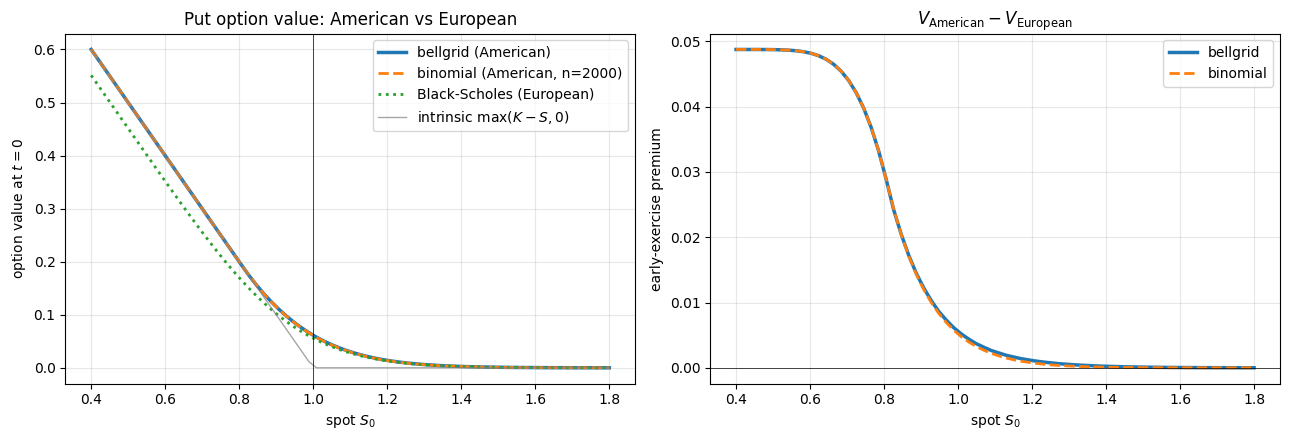

In [5]:
S_grid = np.linspace(0.4, 1.8, 70)
V_bg = value(
    {"price": torch.tensor(S_grid, dtype=torch.float64)}, t=0
).numpy()
V_binom = np.array([
    binomial_american_put(s, K, r, sigma, T_years, n_steps=2000)
    for s in S_grid
])
V_eur = np.array([
    european_put_black_scholes(s, K, r, sigma, T_years) for s in S_grid
])
intrinsic = np.maximum(K - S_grid, 0.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(S_grid, V_bg, lw=2.5, label="bellgrid (American)")
ax1.plot(S_grid, V_binom, ls="--", lw=2, label="binomial (American, n=2000)")
ax1.plot(S_grid, V_eur, ls=":", lw=2, label="Black-Scholes (European)")
ax1.plot(S_grid, intrinsic, lw=1, color="gray", alpha=0.7, label="intrinsic $\\max(K-S, 0)$")
ax1.axvline(K, color="black", lw=0.5)
ax1.set_xlabel("spot $S_0$")
ax1.set_ylabel("option value at $t=0$")
ax1.set_title("Put option value: American vs European")
ax1.legend()
ax1.grid(alpha=0.3)

# Early-exercise premium: V_American - V_European
ax2.plot(S_grid, V_bg - V_eur, lw=2.5, label="bellgrid")
ax2.plot(S_grid, V_binom - V_eur, ls="--", lw=2, label="binomial")
ax2.axhline(0.0, color="black", lw=0.5)
ax2.set_xlabel("spot $S_0$")
ax2.set_ylabel("early-exercise premium")
ax2.set_title("$V_{\\mathrm{American}} - V_{\\mathrm{European}}$")
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Bellgrid vs binomial: residual at the same spot

Quantitative agreement across spot. At every $S_0$ the bellgrid value
matches the high-resolution binomial reference to within a few basis
points.

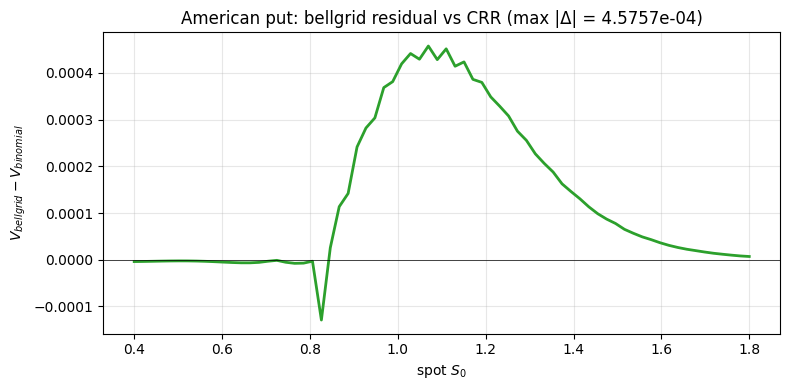

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(S_grid, V_bg - V_binom, lw=2, color="C2")
ax.axhline(0.0, color="black", lw=0.5)
ax.set_xlabel("spot $S_0$")
ax.set_ylabel("$V_{bellgrid} - V_{binomial}$")
ax.set_title(f"American put: bellgrid residual vs CRR (max |Δ| = {np.abs(V_bg - V_binom).max():.4e})")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Optimal action and the exercise boundary

At $t = 0$ the optimal action is a step function in spot: exercise
(action = 1) for $S \lesssim S^*(0)$, hold (action = 0) above.
Sweeping over $t$ traces the **exercise boundary curve** $S^*(t)$.
It rises monotonically toward $K$ as expiry approaches: with less
remaining time, the option's continuation value shrinks and exercise
becomes optimal at higher and higher spot levels.

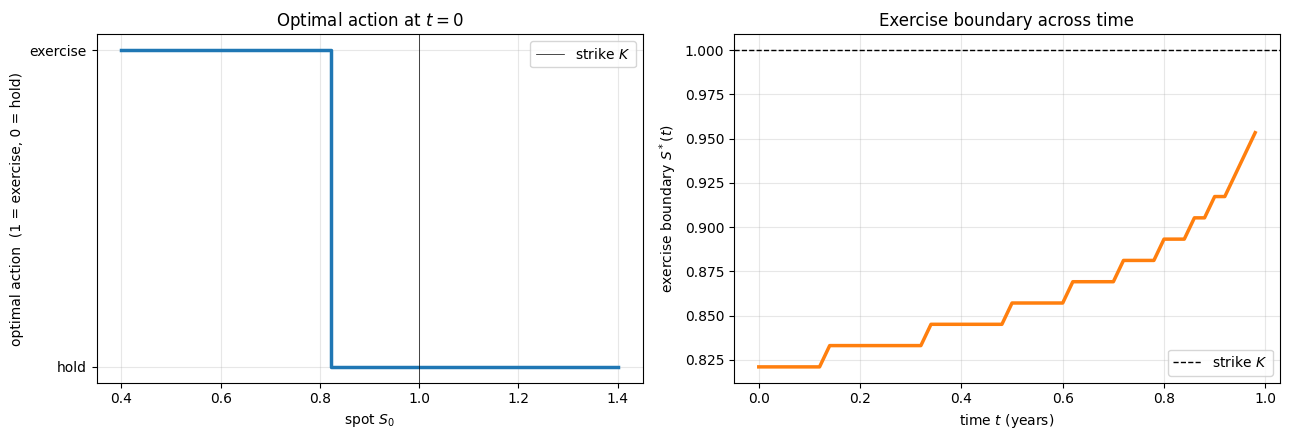

In [7]:
S_dense = np.linspace(0.4, 1.4, 200)
action_at_0 = policy(
    {"price": torch.tensor(S_dense, dtype=torch.float64)}, t=0
)["exercise"].numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.step(S_dense, action_at_0, where="post", lw=2.5, color="C0")
ax1.axvline(K, color="black", lw=0.5, label="strike $K$")
ax1.set_xlabel("spot $S_0$")
ax1.set_ylabel("optimal action  (1 = exercise, 0 = hold)")
ax1.set_yticks([0, 1])
ax1.set_yticklabels(["hold", "exercise"])
ax1.set_title("Optimal action at $t = 0$")
ax1.legend()
ax1.grid(alpha=0.3)

# Exercise boundary across time: largest S for which exercise=1 at each t
S_search = np.linspace(0.0, K * 1.2, 400)
boundary = []
for t in range(n_steps):
    a = policy(
        {"price": torch.tensor(S_search, dtype=torch.float64)}, t=t
    )["exercise"].numpy()
    idx = np.where(a == 1)[0]
    boundary.append(S_search[idx[-1]] if len(idx) > 0 else 0.0)

t_axis = np.arange(n_steps) * dt
ax2.plot(t_axis, boundary, lw=2.5, color="C1")
ax2.axhline(K, color="black", ls="--", lw=1, label="strike $K$")
ax2.set_xlabel("time $t$ (years)")
ax2.set_ylabel("exercise boundary $S^*(t)$")
ax2.set_title("Exercise boundary across time")
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Detailed table: spot sweep

Bellgrid vs binomial vs European put across a sweep of moneyness, with
the optimal action at each spot.

In [8]:
spot_table = [0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.2, 1.4]
print(f"{'S0':>6} {'V_bellgrid':>12} {'V_binomial':>12} {'V_european':>12}"
      f" {'EE_premium':>11} {'optimal_a':>10}")
print("-" * 70)
for S0 in spot_table:
    s = torch.tensor([S0], dtype=torch.float64)
    v_bg = value({"price": s}, t=0).item()
    v_bin = binomial_american_put(S0, K, r, sigma, T_years, n_steps=2000)
    v_eur = european_put_black_scholes(S0, K, r, sigma, T_years)
    a = policy({"price": s}, t=0)["exercise"].item()
    print(f"{S0:>6.2f} {v_bg:>12.5f} {v_bin:>12.5f} {v_eur:>12.5f}"
          f" {v_bg - v_eur:>+11.5f} {a:>10d}")

    S0   V_bellgrid   V_binomial   V_european  EE_premium  optimal_a
----------------------------------------------------------------------


  0.60      0.39999      0.40000      0.35177    +0.04822          1


  0.70      0.29999      0.30000      0.25564    +0.04435          1


  0.80      0.19999      0.20000      0.16982    +0.03017          1


  0.85      0.15316      0.15316      0.13337    +0.01980          0


...

  1.00      0.06129      0.06090      0.05574    +0.00556          0


  1.05      0.04347      0.04305      0.03981    +0.00366          0


  1.10      0.03032      0.02987      0.02786    +0.00246          0


  1.20      0.01403      0.01367      0.01292    +0.00111          0


  1.40      0.00257      0.00243      0.00234    +0.00024          0
